# Cell 1 — Mount Drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Cell 2 — Dataset path

In [2]:
dataset_path = '/content/drive/MyDrive/DEEPLRL_Data'

# Cell 3 — Imports


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Cell 4 — Data generators (augmentation added to train only)


In [4]:
# Training generator now includes augmentation to reduce overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Validation only rescales — no augmentation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Cell 5 — Load training data


In [6]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 326 images belonging to 5 classes.


In [15]:
validation_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 79 images belonging to 5 classes.


# Cell 7 — Compute class weights


In [7]:
# Compute class weights to handle imbalanced dataset
# HDMI has only 18 images vs 117 for SATA
labels = train_data.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)
print("Class indices:", train_data.class_indices)

Class weights: {0: np.float64(4.346666666666667), 1: np.float64(0.9183098591549296), 2: np.float64(0.6936170212765957), 3: np.float64(0.8049382716049382), 4: np.float64(1.003076923076923)}
Class indices: {'hdmi': 0, 'rj45': 1, 'sata': 2, 'usba': 3, 'vga': 4}


# Cell 8 — Build model


In [8]:
model = models.Sequential()

# Block 1
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# Block 2
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# Block 3 (new — helps learn finer connector features)
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# GlobalAveragePooling reduces overfitting vs Flatten
model.add(layers.GlobalAveragePooling2D())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))  # Prevents memorization

model.add(layers.Dense(train_data.num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Cell 9 — Compile

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Cell 10 — Callbacks

In [10]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# Cell 11 — Train


In [14]:
history = model.fit(
    train_data,
    epochs=30,  # EarlyStopping will stop it when ready
    validation_data=validation_data,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 178s 16s/step - accuracy: 0.6319 - loss: 1.1750 - val_accuracy: 0.3038 - val_loss: 1.5914 - learning_rate: 0.0010
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.8252 - loss: 0.6738 - val_accuracy: 0.3291 - val_loss: 1.5898 - learning_rate: 0.0010
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.8528 - loss: 0.5839 - val_accuracy: 0.3291 - val_loss: 1.6083 - learning_rate: 0.0010
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.9049 - loss: 0.4489 - val_accuracy: 0.3291 - val_loss: 1.6180 - learning_rate: 0.0010
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.9018 - loss: 0.4234 - val_accuracy: 0.4430 - val_loss: 1.5690 - learning_rate: 0.0010
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9233 - loss: 0.3474 - val_accuracy: 0.3671 - val_loss: 1.5526 - learning_rate: 0.0010
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.9233 - loss: 0.3081 - val_accuracy

# Cell 12 — Evaluate



In [16]:
loss, accuracy = model.evaluate(validation_data)
print('Validation Accuracy:', accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5316 - loss: 1.5862
Validation Accuracy: 0.5316455960273743


# Cell 13 — Plot accuracy

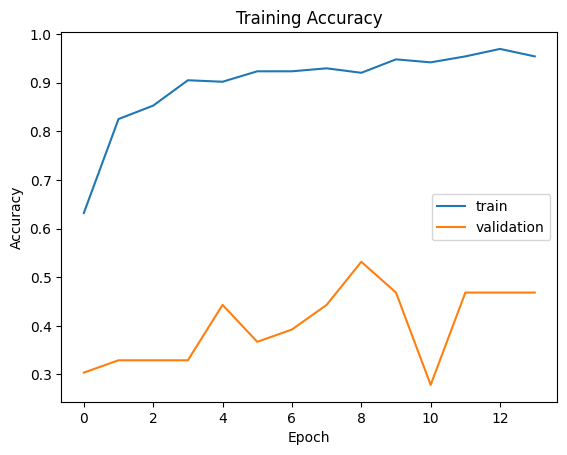

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'validation'])

plt.show()

# Cell 14 — Save model

In [18]:
model.save("cnn_classifier.h5")

# Cell 15 — Download mode

In [19]:
from google.colab import files
files.download("cnn_classifier.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Cell 16 — Test single image in Colab

Saving usb.png to usb.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step


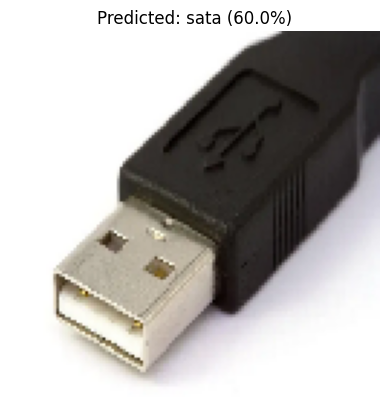

In [20]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = image.load_img(filename, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
confidence = np.max(prediction) * 100

class_labels = list(train_data.class_indices.keys())

plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {class_labels[predicted_class]} ({confidence:.1f}%)")
plt.show()

In [21]:


# Upload image from local computer
uploaded = files.upload()

# Get the uploaded filename
filename = list(uploaded.keys())[0]

# Load and resize image
img = image.load_img(filename, target_size=(128,128))

# Convert image to array
img_array = image.img_to_array(img)

# Normalize pixel values
img_array = img_array / 255.0

# Expand dimensions to match model input
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)

# Get predicted class index
predicted_class = np.argmax(prediction)

# Get class label names
class_labels = list(train_data.class_indices.keys())



Saving usba2.png to usba2.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


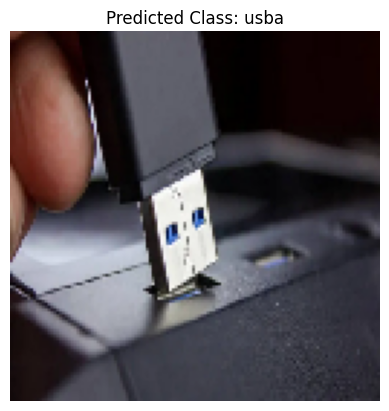

In [22]:
# Display image
plt.imshow(img)
plt.axis('off')
plt.title("Predicted Class: " + class_labels[predicted_class])
plt.show()

# Streamlit Save

In [23]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# ── Page config ──────────────────────────────────────────────
st.set_page_config(
    page_title="Connector Classifier",
    page_icon="🔌",
    layout="centered"
)

st.title("🔌 Network Connector Classifier")
st.write("Upload an image to identify the connector type: **SATA, VGA, USB-A, HDMI, or RJ45**")

# ── Load model (cached so it only loads once) ────────────────
@st.cache_resource
def load_model():
    return tf.keras.models.load_model("cnn_classifier.keras")

model = load_model()

CLASS_LABELS = ['hdmi', 'rj45', 'sata', 'usba', 'vga']  # alphabetical — matches flow_from_directory

# ── Upload ───────────────────────────────────────────────────
uploaded_file = st.file_uploader(
    "Choose an image", type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:
    img = Image.open(uploaded_file).convert("RGB")
    st.image(img, caption="Uploaded image", use_column_width=True)

    # Preprocess
    img_resized = img.resize((128, 128))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    with st.spinner("Classifying..."):
        prediction = model.predict(img_array)[0]

    predicted_idx = np.argmax(prediction)
    predicted_label = CLASS_LABELS[predicted_idx]
    confidence = prediction[predicted_idx] * 100

    # ── Results ──────────────────────────────────────────────
    st.markdown("---")
    col1, col2 = st.columns(2)
    with col1:
        st.metric("Predicted Connector", predicted_label.upper())
    with col2:
        st.metric("Confidence", f"{confidence:.1f}%")

    # Confidence bar chart for all classes
    st.markdown("#### Confidence per class")
    for label, score in zip(CLASS_LABELS, prediction):
        st.progress(
            float(score),
            text=f"{label.upper()}: {score*100:.1f}%"
        )

    if confidence < 60:
        st.warning(
            "⚠️ Low confidence — the model is unsure. "
            "This may be due to limited training data (especially HDMI)."
        )

ModuleNotFoundError: No module named 'streamlit'